<a href="https://colab.research.google.com/github/oxedanda/avcad_final_project/blob/main/notebooks/04_permanent_temporary_crops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

# Raw GitHub URLs
url_temp = "https://raw.githubusercontent.com/oxedanda/avcad_final_project/main/data/processed/temporary_crops_holdings_clean.csv"
url_perm = "https://raw.githubusercontent.com/oxedanda/avcad_final_project/main/data/processed/permanent_crops_holdings_clean.csv"
url_area = "https://raw.githubusercontent.com/oxedanda/avcad_final_project/main/data/processed/agricultural_holdings_area_clean.csv"

# Load datasets
df_temp = pd.read_csv(url_temp)
df_perm = pd.read_csv(url_perm)
df_area = pd.read_csv(url_area)

# Sort datasets by year
df_temp = df_temp.sort_values("year")
df_perm = df_perm.sort_values("year")
df_area = df_area.sort_values("year")

# Define crop categories for temporary crops
temp_crop_cols = [
    "Grain cereals",
    "Dried pulses for grain",
    "Temporary meadows",
    "Forage crops",
    "Potatoes",
    "Sugar beet",
    "Industrial crops",
    "Horticultural crops",
    "Flowers and ornamental plants",
    "Other temporary crops"
]

# Display first rows to verify data loaded correctly
print("Temporary Crops Data:")
print(df_temp.head())
print("\nPermanent Crops Data:")
print(df_perm.head())
print("\nArea Data:")
print(df_area.head())

Temporary Crops Data:
   year geographic_location  code   Total  Grain cereals  \
3  1989          Continente     1  446915         352158   
2  1999          Continente     1  280214         190446   
1  2009          Continente     1  165265         108524   
0  2019          Continente     1  124902          66584   

   Dried pulses for grain  Temporary meadows  Forage crops  Potatoes  \
3                  222230              40645        285468    312443   
2                   87021              19531        180000    163360   
1                   28882              13293        102983     56969   
0                   15945              14066         65416     34570   

   Sugar beet  Industrial crops  Horticultural crops  \
3        33.0              3638                77052   
2       495.0              3738                48610   
1         NaN              1364                18141   
0         NaN              1147                15874   

   Flowers and ornamental plants  O

Table 3.11 - Temporary Crop Holdings

In [36]:
# TABLE Temporary Crop Holdings

# Calculate percentage change from 1989 to 2019
temp_changes = {}
for col in temp_crop_cols:
    val_1989 = temp[col].iloc[0]
    val_2019 = temp[col].iloc[-1]

    if pd.notna(val_1989) and val_1989 != 0:
        temp_changes[col] = ((val_2019 - val_1989) / val_1989) * 100
    else:
        temp_changes[col] = np.nan

# Calculate overall change for Total Temporary Crops
total_temp_1989 = temp['Total'].iloc[0]
total_temp_2019 = temp['Total'].iloc[-1]

if pd.notna(total_temp_1989) and total_temp_1989 != 0:
    total_temp_change = ((total_temp_2019 - total_temp_1989) / total_temp_1989) * 100
else:
    total_temp_change = np.nan

# Create table data
table_data = {
    'Crop Category': ['Total Temporary Crops'] + temp_crop_cols
}

for year in temp['year']:
    values = [temp.loc[temp['year'] == year, 'Total'].values[0]]
    for col in temp_crop_cols:
        values.append(temp.loc[temp['year'] == year, col].values[0])
    table_data[str(year)] = values

# Add change column
change_values = [f"{total_temp_change:.1f}" if pd.notna(total_temp_change) else 'NaN']
for col in temp_crop_cols:
    if pd.notna(temp_changes[col]):
        change_values.append(f"{temp_changes[col]:.1f}")
    else:
        change_values.append('nan')

table_data['Change (%)'] = change_values

# Create dataframe
table_311 = pd.DataFrame(table_data)

# Display table in text format
print("Temporary Crop Holdings by Category (1989–2019)")
print(table_311.to_string(index=False))

# Save table as an image
fig, ax = plt.subplots(figsize=(14, len(table_311) * 0.4 + 1))
ax.axis('off')
ax.axis('tight')
ax.set_title('Temporary Crop Holdings by Category (1989–2019)', loc='left', fontsize=12)

table_img = ax.table(
    cellText=table_311.values,
    colLabels=table_311.columns,
    loc='center',
    cellLoc='center'
)

table_img.auto_set_font_size(False)
table_img.set_fontsize(10)
table_img.auto_set_column_width(col=list(range(len(table_311.columns))))
table_img.scale(1.2, 1.2)

plt.tight_layout()
plt.savefig('temporary_crop_holdings.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Temporary Crop Holdings by Category (1989–2019)
                Crop Category     1989     1999     2009     2019 Change (%)
        Total Temporary Crops 446915.0 280214.0 165265.0 124902.0      -72.1
                Grain cereals 352158.0 190446.0 108524.0  66584.0      -81.1
       Dried pulses for grain 222230.0  87021.0  28882.0  15945.0      -92.8
            Temporary meadows  40645.0  19531.0  13293.0  14066.0      -65.4
                 Forage crops 285468.0 180000.0 102983.0  65416.0      -77.1
                     Potatoes 312443.0 163360.0  56969.0  34570.0      -88.9
                   Sugar beet     33.0    495.0      NaN      NaN        nan
             Industrial crops   3638.0   3738.0   1364.0   1147.0      -68.5
          Horticultural crops  77052.0  48610.0  18141.0  15874.0      -79.4
Flowers and ornamental plants   1788.0   1744.0   1056.0   1005.0      -43.8
        Other temporary crops  65133.0  20662.0   1424.0   1718.0      -97.4


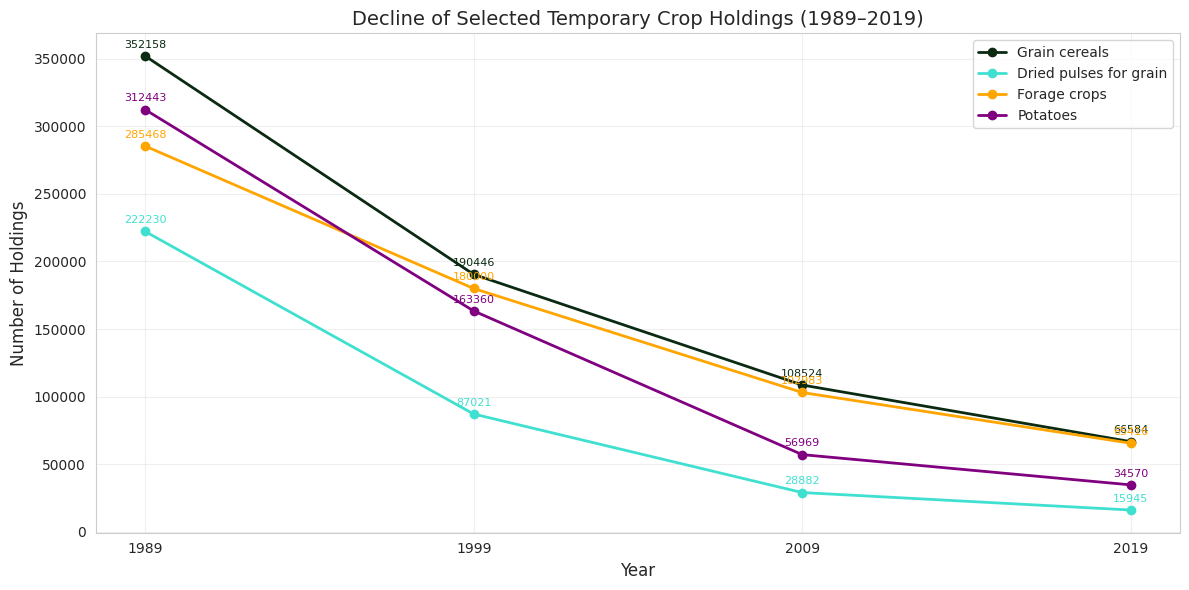

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

specific_crops = ['Grain cereals', 'Dried pulses for grain', 'Forage crops', 'Potatoes']
colors_decline = ['#0A2A12', '#40E0D0', '#FFA500', '#800080']

for i, crop in enumerate(specific_crops):
    ax.plot(
        temp['year'],
        temp[crop],
        marker='o',
        linewidth=2,
        markersize=6,
        color=colors_decline[i],
        label=crop
    )

ax.set_title('Decline of Selected Temporary Crop Holdings (1989–2019)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_xticks([1989, 1999, 2009, 2019])
ax.set_xticklabels([1989, 1999, 2009, 2019])
ax.grid(True, alpha=0.3)
ax.legend()

for i, crop in enumerate(specific_crops):
    for year in [1989, 1999, 2009, 2019]:
        value = temp.loc[temp['year'] == year, crop].values[0]
        ax.annotate(
            f'{int(value)}',
            (year, value),
            textcoords='offset points',
            xytext=(0, 6),
            ha='center',
            fontsize=8,
            color=colors_decline[i]
        )

plt.tight_layout()
plt.savefig('figure_decline_selected_temporary_crops.png', dpi=300, bbox_inches='tight')
plt.show()

Table - Permanent Crop Holdings

In [34]:
# Display table in text format
print("Permanent Crop Holdings by Category (1989–2019)")
print(table_312.to_string(index=False))


# Save table as an image
fig, ax = plt.subplots(figsize=(14, len(table_312) * 0.4 + 1))
ax.axis('off')
ax.axis('tight')
ax.set_title('Permanent Crop Holdings by Category (1989–2019)', loc='left', fontsize=12)

table_img = ax.table(
    cellText=table_312.values,
    colLabels=table_312.columns,
    loc='center',
    cellLoc='center'
)

table_img.auto_set_font_size(False)
table_img.set_fontsize(10)
table_img.auto_set_column_width(col=list(range(len(table_312.columns))))
table_img.scale(1.2, 1.2)

plt.tight_layout()
plt.savefig('permanent_crop_holdings.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Permanent Crop Holdings by Category (1989–2019)
 Year  Total Permanent Holdings Change from Previous Period Cumulative Change
 1989                    453441                           -                 -
 1999                    320484                      -29.3%            -29.3%
 2009                    225806                      -29.5%            -58.9%
 2019                    205208                       -9.1%            -68.0%


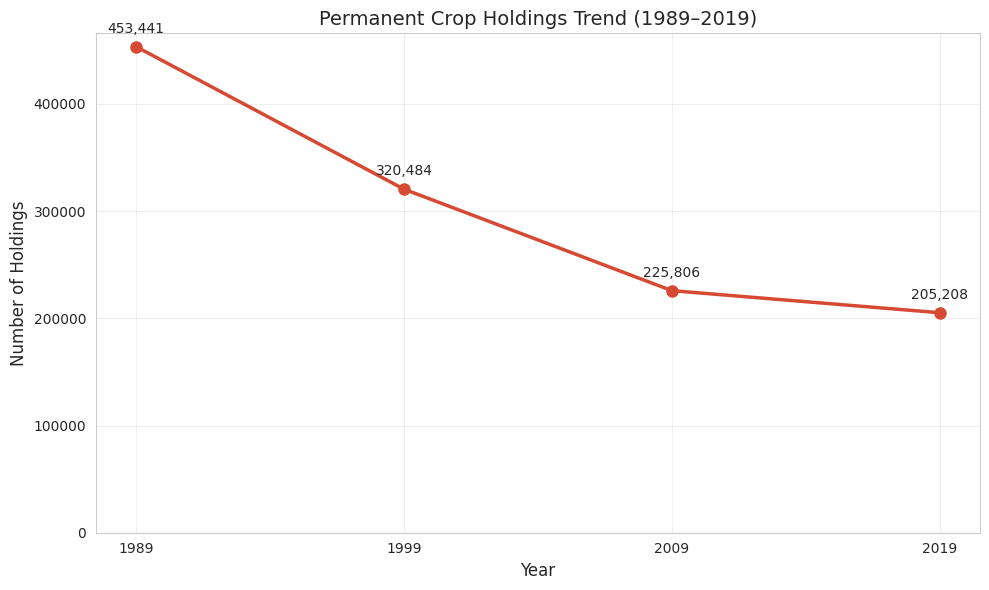

In [31]:
# ============================================
# NEW FIGURE: Permanent Crop Holdings Trend
# ============================================

fig_trend, ax_trend = plt.subplots(figsize=(10, 6))

ax_trend.plot(perm['year'], perm['Total'], 'o-', color='#D64933', linewidth=2.5, markersize=8)

ax_trend.set_xlabel('Year', fontsize=12)
ax_trend.set_ylabel('Number of Holdings', fontsize=12)
ax_trend.set_title('Permanent Crop Holdings Trend (1989–2019)', fontsize=14)
ax_trend.grid(True, alpha=0.3)
ax_trend.set_ylim(bottom=0)
ax_trend.set_xticks(perm['year'])

# Add value labels for each point
for i, year in enumerate(perm['year']):
    ax_trend.annotate(f"{perm['Total'].iloc[i]:,}",
               (year, perm['Total'].iloc[i]),
               xytext=(0, 10), textcoords='offset points',
               ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('figure_permanent_crop_trend.png', dpi=300, bbox_inches='tight')
plt.show()

Table 3.13 - Comparative Analysis


Table 3.13 — Comparative Analysis: Temporary vs. Permanent Crops
                     Indicator    Temporary Crops    Permanent Crops
      Total change (1989–2019)             -72.1%             -54.7%
  Period of most rapid decline 1989–1999 (-37.3%) 1989–1999 (-29.3%)
     Period of slowest decline 2009–2019 (-24.4%)  2009–2019 (-9.1%)
Share of total holdings (2019)              37.8%              62.2%


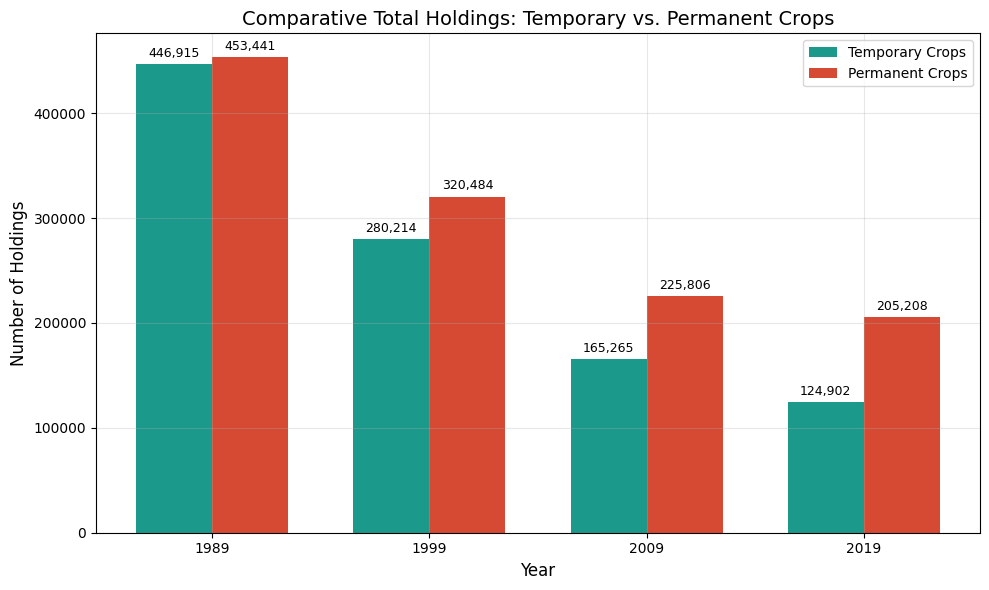

In [ ]:
# ============================================
# TABLE 3.13: Comparative Analysis
# ============================================

temp_1989 = temp['Total'].iloc[0]
temp_1999 = temp['Total'].iloc[1]
temp_2009 = temp['Total'].iloc[2]
temp_2019 = temp['Total'].iloc[-1]

perm_1989 = perm['Total'].iloc[0]
perm_1999 = perm['Total'].iloc[1]
perm_2009 = perm['Total'].iloc[2]
perm_2019 = perm['Total'].iloc[-1]

table_313 = pd.DataFrame({
    'Indicator': ['Total change (1989–2019)', 'Period of most rapid decline', 'Period of slowest decline', 'Share of total holdings (2019)'],
    'Temporary Crops': [
        f"{((temp_2019 - temp_1989) / temp_1989 * 100):.1f}%",
        f"1989–1999 ({((temp_1999 - temp_1989) / temp_1989 * 100):.1f}%)",
        f"2009–2019 ({((temp_2019 - temp_2009) / temp_2009 * 100):.1f}%)",
        f"{temp_2019 / (temp_2019 + perm_2019) * 100:.1f}%"
    ],
    'Permanent Crops': [
        f"{((perm_2019 - perm_1989) / perm_1989 * 100):.1f}%",
        f"1989–1999 ({((perm_1999 - perm_1989) / perm_1989 * 100):.1f}%)",
        f"2009–2019 ({((perm_2019 - perm_2009) / perm_2009 * 100):.1f}%)",
        f"{perm_2019 / (temp_2019 + perm_2019) * 100:.1f}%"
    ]
})

print("\nTable 3.13 — Comparative Analysis: Temporary vs. Permanent Crops")
print(table_313.to_string(index=False))

# ============================================
# NEW FIGURE: Comparative Holdings Bar Chart (Histogram-like)
# ============================================

# Prepare data for the bar chart
years = temp['year'].astype(str)
temp_totals = temp['Total']
perm_totals = perm['Total']

x = np.arange(len(years))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, temp_totals, width, label='Temporary Crops', color='#1B998B')
rects2 = ax.bar(x + width/2, perm_totals, width, label='Permanent Crops', color='#D64933')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Holdings', fontsize=12)
ax.set_title('Comparative Total Holdings: Temporary vs. Permanent Crops', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on top of the bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure_comparative_total_holdings_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()